# Gradient Descent Exploration

We shall explore the behavior of the descent algorithms in more detail.

We shall keep to linear model, however, in the vector form $$y = \theta^T \mathbf{x}$$ 
Remember that this is equivalent to the simple $$y = \theta_0 + \theta_1 x \quad \text{ with } \quad \mathbf{x} = [1, x]$$

In [1]:
# magic for autoreloading of modules
%reload_ext autoreload
%autoreload 2

# import libraries
import torch
import numpy as np  # for csv loading and plotting
from helpers import data, plot_model, loss_contour, plot_loss
import todos as td

The `data` here is a `torch.tensor` with shape `torch.Size([12, 2])` with inputs $x$ in the first column and output $y$ in the second column.

We will initialize the 2d parameter vector $\theta$ randomly.

<span style="color:red">**TODO 1:**</span> define the `linear_model` and `mse` functions in the `todos.py`.

In [2]:
# initialize parameters
theta = torch.rand(2,1)
print(f'theta: {theta}')

# predict y
x = data[:,:1]
y = data[:,1:]
y_pred = td.linear_model(x,theta)

# get mse
mse = td.mse(y, y_pred)
print(f'Initial mse: {mse}')

theta: tensor([[0.3331],
        [0.2235]])
Initial mse: 0.6510999798774719


We next plot the data, the initial model and the loss contours with the initial parameters.

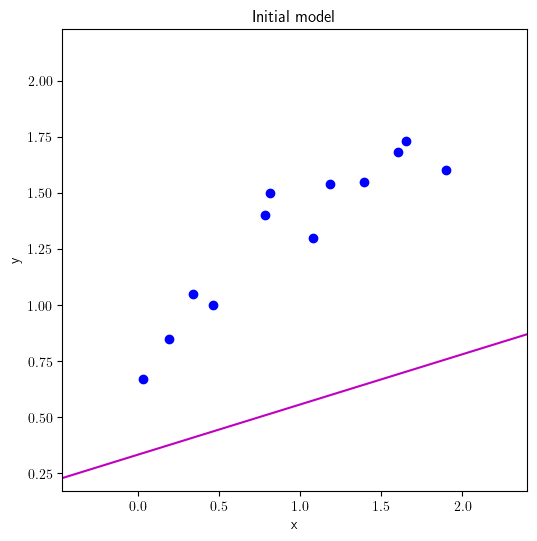

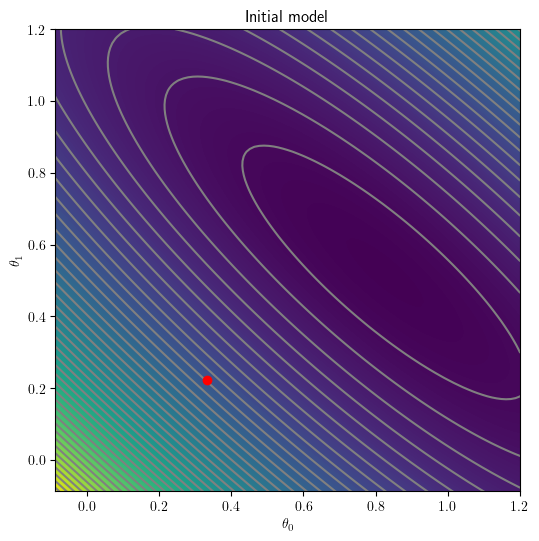

In [3]:
# plot initial model
plot_model(x, y, theta, model=td.linear_model, title="Initial model")

# plot loss contour
loss_contour(x,y,model=td.linear_model,loss_func=td.mse,title="Initial model",theta_list=theta)

<span style="color:red">**TODO 2:**</span> 
complete the gradient descent algorithm in the `todos.py` so that it operates over parameters $\theta$ as a vector and stores the history of the steps into a `torch.tensor`.

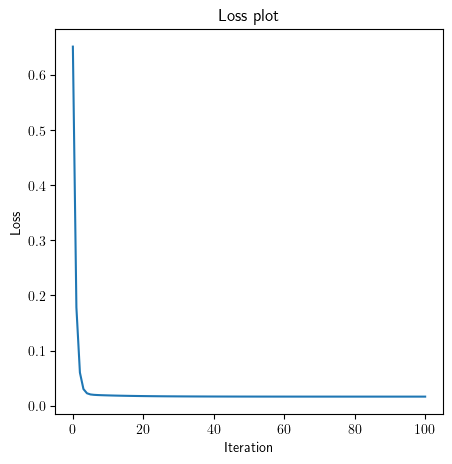

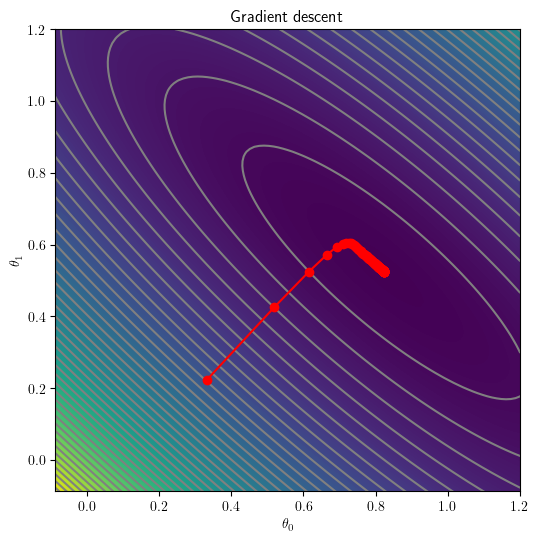

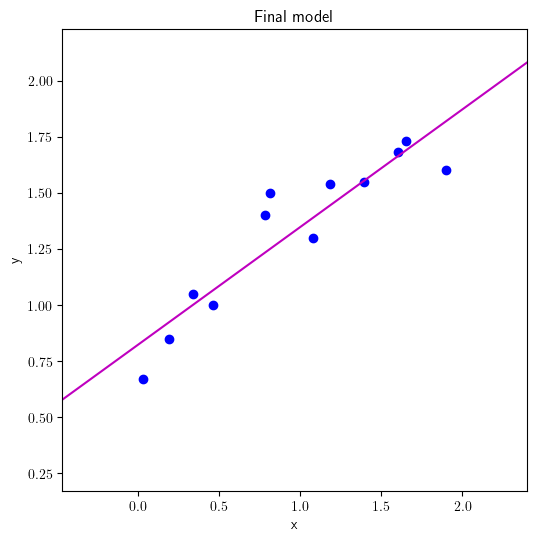

Final mse: 0.016656972467899323


In [6]:
# gradient descent
thetas, losses = td.grad_descent(x,y, theta,grad_func=td.lin_grads,model=td.linear_model, lr=0.01,n_epochs=100)

# plot losses
plot_loss(losses)

# plot loss contour
loss_contour(x,y,model=td.linear_model,loss_func=td.mse,title="Gradient descent",theta_list=thetas) 

# plot final model
plot_model(x, y, thetas[:,-1], model=td.linear_model, title="Final model")

# get mse
y_pred = td.linear_model(x,thetas[:,-1:])
mse = td.mse(y, y_pred)
print(f'Final mse: {mse}')